# Teste de Performance: 
Compara o Random Forest do scikit-learn com o método `onto_rf` variando o número de features.

In [1]:
import numpy as np
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from onto_rf import ClusterAwareRandomForestClassifier, LightClusterAwareRandomForestClassifier


In [2]:
DATASET = "BLCA"

# Carregando dados
_mrna  = pd.read_csv(f'data/input/tcga_full/{DATASET}_data/mRNA_data.csv')
_resp  = pd.read_csv(f'data/input/tcga_full/{DATASET}_data/response.csv')
merged = _mrna.merge(_resp[['Case_ID', 'response']], on='Case_ID')

X_full = merged.drop(columns=['Case_ID', 'response'])
y = merged['response'].values

# Carregando clusters
df_clusters  = pd.read_csv(f'data/output/tcga_full/clusters/genes_clustered_kegg_{DATASET}.csv')
cluster_map  = df_clusters[['gene', 'cluster_hdbscan']]

print(f"Data shape: {X_full.shape}")

Data shape: (469, 20530)


In [3]:
def benchmark_rf(clf_class, clf_params, X, y, n_tests=3, test_size=0.3):
    accuracies = []
    f1_scores = []
    train_times = []
    test_times = []
    for i in range(n_tests):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=i)
        model = clf_class(**clf_params)
        
        # Training
        start = time.time()
        model.fit(X_train, y_train)
        train_times.append(time.time() - start)
        
        # Testing
        start = time.time()
        y_pred = model.predict(X_test)
        test_times.append(time.time() - start)
        
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        f1 = classification_report(y_test, y_pred, output_dict=True, zero_division=0)['weighted avg']['f1-score']
        f1_scores.append(f1)
        
    return pd.DataFrame({
        'implementation': [clf_class.__name__]*n_tests,
        'n_features': [X.shape[1]]*n_tests,
        'n_samples': [X.shape[0]]*n_tests,
        'seed': list(range(n_tests)),
        'accuracy': accuracies,
        'f1': f1_scores,
        'train_time': train_times,
        'test_time': test_times})

In [4]:
features_interval = [100, 500, 1000, 2000, 5000, 10000, 15000, X_full.shape[1]]
n_tests = 5 # Poucas repeticoes porque e custoso
n_jobs = -1

results = []
for n_features in tqdm(features_interval):
    actual_features = min(n_features, X_full.shape[1])
    # Evitar features duplicadas se X_full.shape[1] ja for algum dos anteriores
    if actual_features != n_features and actual_features in features_interval:
        continue
    
    np.random.seed(42)
    selected_features = np.random.choice(X_full.columns, actual_features, replace=False)
    
    X_sub = X_full[selected_features]
    
    current_cluster_map = cluster_map[cluster_map['gene'].isin(selected_features)]
    
    onto_params = {'clusters': current_cluster_map, 'n_estimators': 100, 'n_jobs': n_jobs, 'random_state': 42}
    rf_params = {'n_estimators': 100, 'n_jobs': n_jobs, 'random_state': 42}
    
    res_onto = benchmark_rf(ClusterAwareRandomForestClassifier, onto_params, X_sub, y, n_tests=n_tests)
    res_light = benchmark_rf(LightClusterAwareRandomForestClassifier, onto_params, X_sub, y, n_tests=n_tests)
    res_rf = benchmark_rf(RandomForestClassifier, rf_params, X_sub, y, n_tests=n_tests)
    
    results.extend([res_onto, res_light, res_rf])

final = pd.concat(results, ignore_index=True)
display(final.groupby(['implementation', 'n_features'])[['train_time', 'test_time', 'f1']].mean())

100%|██████████| 8/8 [22:32<00:00, 169.11s/it]


train_time  test_time  \
implementation                          n_features                          
ClusterAwareRandomForestClassifier      100           5.325934   0.046796   
                                        500          11.092036   0.052771   
                                        1000         15.016245   0.052017   
                                        2000         21.766062   0.063849   
                                        5000         33.857530   0.106269   
                                        10000        45.617074   0.088450   
                                        15000        54.538623   0.120571   
                                        20530        63.255671   0.132662   
LightClusterAwareRandomForestClassifier 100           0.102587   0.014279   
                                        500           0.280054   0.018348   
                                        1000          0.329326   0.019540   
                                        2000          0.408616   0.055032   
                                        5000          0.726198   0.038584   
                                        10000         1.401643   0.059242   
                                        15000         2.284943   0.076013   
                                        20530         2.871154   0.097190   
RandomForestClassifier                  100           0.208230   0.035764   
                                        500           0.221506   0.044564   
                                        1000          0.220535   0.052110   
                                        2000          0.246554   0.062412   
                                        5000          0.348203   0.143789   
                                        10000         0.419886   0.170049   
                                        15000         0.496705   0.215299   
                                        20530         0.581123   0.327272   

                                                          f1  
implementation                          n_features            
ClusterAwareRandomForestClassifier      100         0.616862  
                                        500         0.633481  
                                        1000        0.637576  
                                        2000        0.625567  
                                        5000        0.622034  
                                        10000       0.629393  
                                        15000       0.628093  
                                        20530       0.624439  
LightClusterAwareRandomForestClassifier 100         0.584590  
                                        500         0.598128  
                                        1000        0.613895  
                                        2000        0.641477  
                                        5000        0.624539  
                                        10000       0.609556  
                                        15000       0.616835  
                                        20530       0.636105  
RandomForestClassifier                  100         0.611678  
                                        500         0.580753  
                                        1000        0.616867  
                                        2000        0.613250  
                                        5000        0.610398  
                                        10000       0.618076  
                                        15000       0.620919  
                                        20530       0.635118

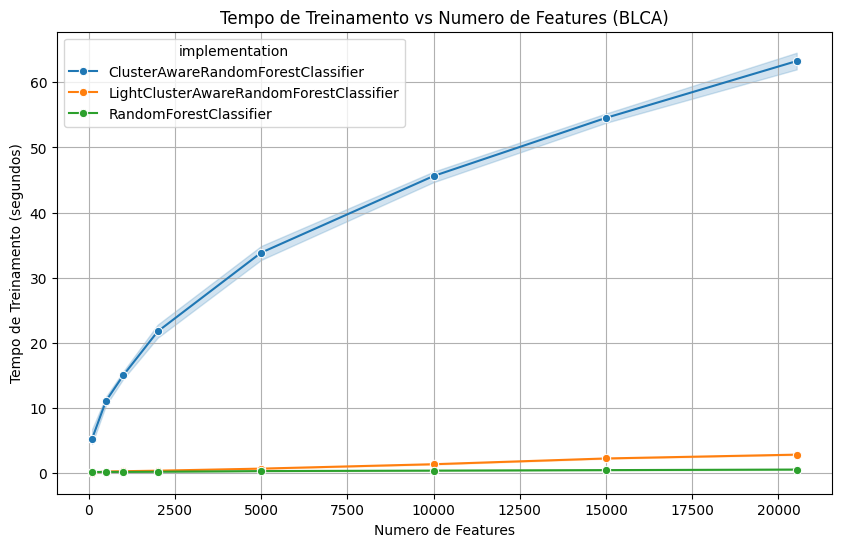

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
ax = sns.lineplot(data=final, x='n_features', y='train_time', hue='implementation', marker='o')
ax.set_ylabel('Tempo de Treinamento (segundos)')
ax.set_xlabel('Numero de Features')
ax.set_title('Tempo de Treinamento vs Numero de Features (BLCA)')
plt.grid(True)
plt.show()